In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,recall_score, f1_score,roc_auc_score, confusion_matrix,roc_curve, classification_report)
import xgboost as xgb
import lightgbm as lgb

df = pd.read_csv(r'C:\Users\sadeq\Desktop\Python\Hotel_Booking\data\hotel_bookings_clean.csv')

df['arrival_date'] = pd.to_datetime(df['arrival_date'])

# Section 1 Feature Selection

In [3]:
# Drop leakage, ID, and redundant columns

drop_cols = [
    'booking_id',           
    'reservation_status',   
    'reservation_status_date',
    'arrival_date',         
    'is_complimentary',   
    'is_zero_guest',        
    'is_same_day',        
]

df_ml = df.drop(columns=drop_cols)

X = df_ml.drop(columns=['is_canceled'])
y = df_ml['is_canceled']

print(f"Features: {X.shape[1]}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\nFeature list:")
for col in X.columns:
    print(f"  {col} — {X[col].dtype}")

Features: 38
Target distribution:
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Feature list:
  hotel — str
  lead_time — int64
  arrival_date_year — int64
  arrival_date_month — str
  arrival_date_week_number — int64
  arrival_date_day_of_month — int64
  stays_in_weekend_nights — int64
  stays_in_week_nights — int64
  adults — int64
  children — int64
  babies — int64
  adr — float64
  booking_changes — int64
  days_in_waiting_list — int64
  required_car_parking_spaces — int64
  total_of_special_requests — int64
  country — str
  is_repeated_guest — int64
  previous_cancellations — int64
  previous_bookings_not_canceled — int64
  meal — str
  market_segment — str
  distribution_channel — str
  reserved_room_type — str
  assigned_room_type — str
  deposit_type — str
  agent — int64
  company — int64
  customer_type — str
  total_nights — int64
  total_revenue — float64
  is_weekend_arrival — int64
  season — str
  lead_time_bucket — str
  room_match — int64
  is_family —

In [4]:
# Encode categorical columns

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
le = LabelEncoder()
X_encoded = X.copy()

for col in cat_cols:
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

In [5]:
# Train/test split: 80% train, 20% test

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)

print(f"Training set:   {X_train.shape[0]:,} rows")
print(f"Test set:       {X_test.shape[0]:,} rows")

Training set:   95,512 rows
Test set:       23,878 rows


In [6]:
# Scale features for Logistic Regression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Section 2 Model Building

In [7]:
# Model 1 Logistic Regression

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

print(f"\nLogistic Regression Results:")
print(f"  Accuracy:  {accuracy_score(y_test, lr_pred)*100:.2f}%")
print(f"  Precision: {precision_score(y_test, lr_pred)*100:.2f}%")
print(f"  Recall:    {recall_score(y_test, lr_pred)*100:.2f}%")
print(f"  F1 Score:  {f1_score(y_test, lr_pred)*100:.2f}%")
print(f"  ROC-AUC:   {roc_auc_score(y_test, lr_prob)*100:.2f}%")


Logistic Regression Results:
  Accuracy:  80.09%
  Precision: 80.18%
  Recall:    61.42%
  F1 Score:  69.56%
  ROC-AUC:   87.35%


In [8]:
# Model 2 Random Forest

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print(f"\nRandom Forest Results:")
print(f"  Accuracy:  {accuracy_score(y_test, rf_pred)*100:.2f}%")
print(f"  Precision: {precision_score(y_test, rf_pred)*100:.2f}%")
print(f"  Recall:    {recall_score(y_test, rf_pred)*100:.2f}%")
print(f"  F1 Score:  {f1_score(y_test, rf_pred)*100:.2f}%")
print(f"  ROC-AUC:   {roc_auc_score(y_test, rf_prob)*100:.2f}%")


Random Forest Results:
  Accuracy:  87.40%
  Precision: 88.66%
  Recall:    75.67%
  F1 Score:  81.65%
  ROC-AUC:   94.82%


In [9]:
# Model 3 XGBoost

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print(f"\nXGBoost Results:")
print(f"  Accuracy:  {accuracy_score(y_test, xgb_pred)*100:.2f}%")
print(f"  Precision: {precision_score(y_test, xgb_pred)*100:.2f}%")
print(f"  Recall:    {recall_score(y_test, xgb_pred)*100:.2f}%")
print(f"  F1 Score:  {f1_score(y_test, xgb_pred)*100:.2f}%")
print(f"  ROC-AUC:   {roc_auc_score(y_test, xgb_prob)*100:.2f}%")


XGBoost Results:
  Accuracy:  87.91%
  Precision: 86.11%
  Recall:    80.32%
  F1 Score:  83.11%
  ROC-AUC:   95.29%


In [10]:
# Model 4 LightGBM

lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)
lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_test)
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]

print(f"\nLightGBM Results:")
print(f"  Accuracy:  {accuracy_score(y_test, lgb_pred)*100:.2f}%")
print(f"  Precision: {precision_score(y_test, lgb_pred)*100:.2f}%")
print(f"  Recall:    {recall_score(y_test, lgb_pred)*100:.2f}%")
print(f"  F1 Score:  {f1_score(y_test, lgb_pred)*100:.2f}%")
print(f"  ROC-AUC:   {roc_auc_score(y_test, lgb_prob)*100:.2f}%")


LightGBM Results:
  Accuracy:  87.85%
  Precision: 86.15%
  Recall:    80.06%
  F1 Score:  82.99%
  ROC-AUC:   95.24%


====================================================================================================================================================================================================================================


# Section 3 Model Comparison and Evaluation

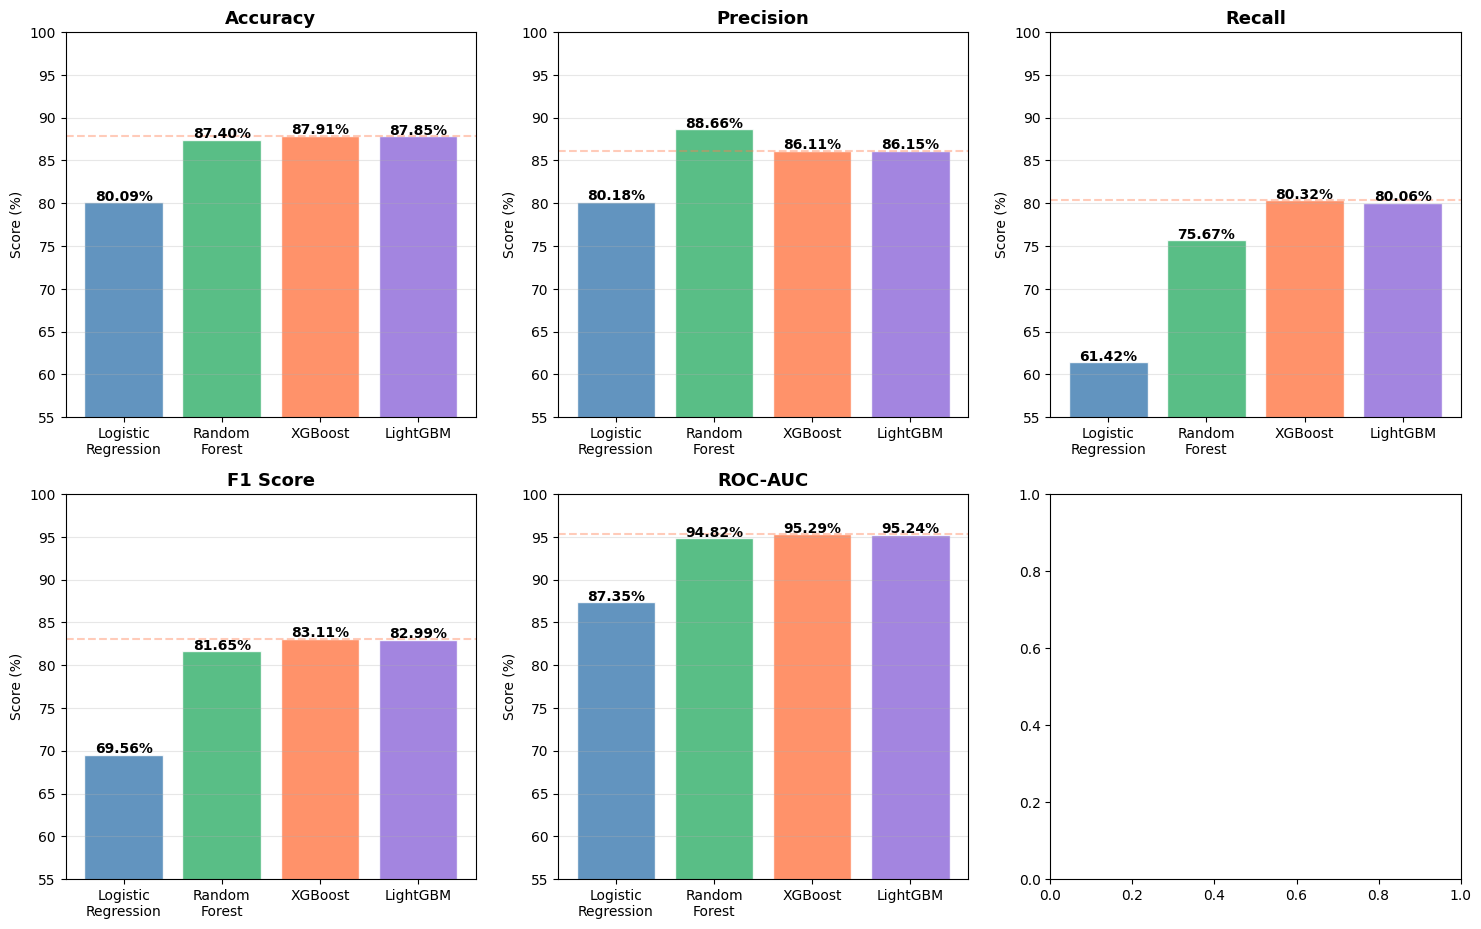

In [11]:

models = ['Logistic\nRegression', 'Random\nForest', 'XGBoost', 'LightGBM']

results = {
    'Accuracy':  [80.09, 87.40, 87.91, 87.85],
    'Precision': [80.18, 88.66, 86.11, 86.15],
    'Recall':    [61.42, 75.67, 80.32, 80.06],
    'F1 Score':  [69.56, 81.65, 83.11, 82.99],
    'ROC-AUC':   [87.35, 94.82, 95.29, 95.24]
}

colors = ['steelblue', 'mediumseagreen', 'coral', 'mediumpurple']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, (metric, values) in enumerate(results.items()):
    bars = axes[i].bar(models, values, color=colors,
                       edgecolor='white', alpha=0.85)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.2,
                     f'{val:.2f}%', ha='center',
                     fontweight='bold', fontsize=10)
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Score (%)')
    axes[i].set_ylim(55, 100)
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].axhline(y=values[2], color='coral',
                    linestyle='--', alpha=0.4)






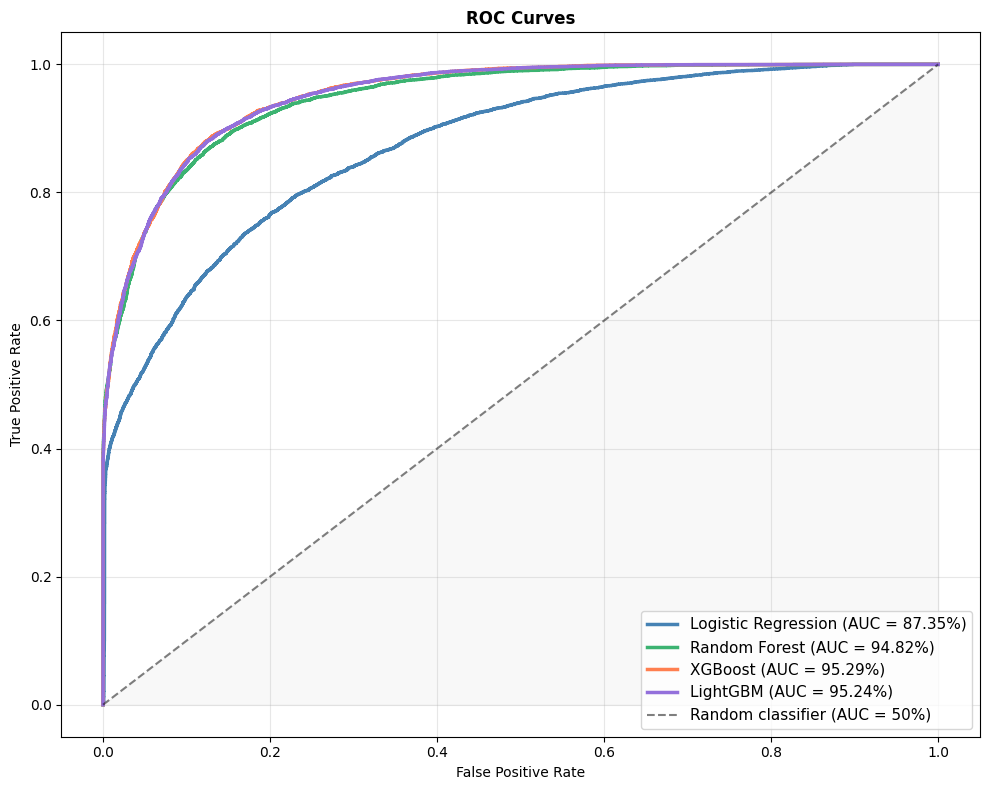

In [12]:
# ROC Curves 

fig, ax = plt.subplots(figsize=(10, 8))

models_roc = [
    ('Logistic Regression', lr_prob, 'steelblue'),
    ('Random Forest',       rf_prob, 'mediumseagreen'),
    ('XGBoost',             xgb_prob, 'coral'),
    ('LightGBM',            lgb_prob, 'mediumpurple')
]

for name, prob, color in models_roc:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name} (AUC = {auc*100:.2f}%)')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5,
        alpha=0.5, label='Random classifier (AUC = 50%)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

ax.set_title('ROC Curves',
             fontsize=12, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

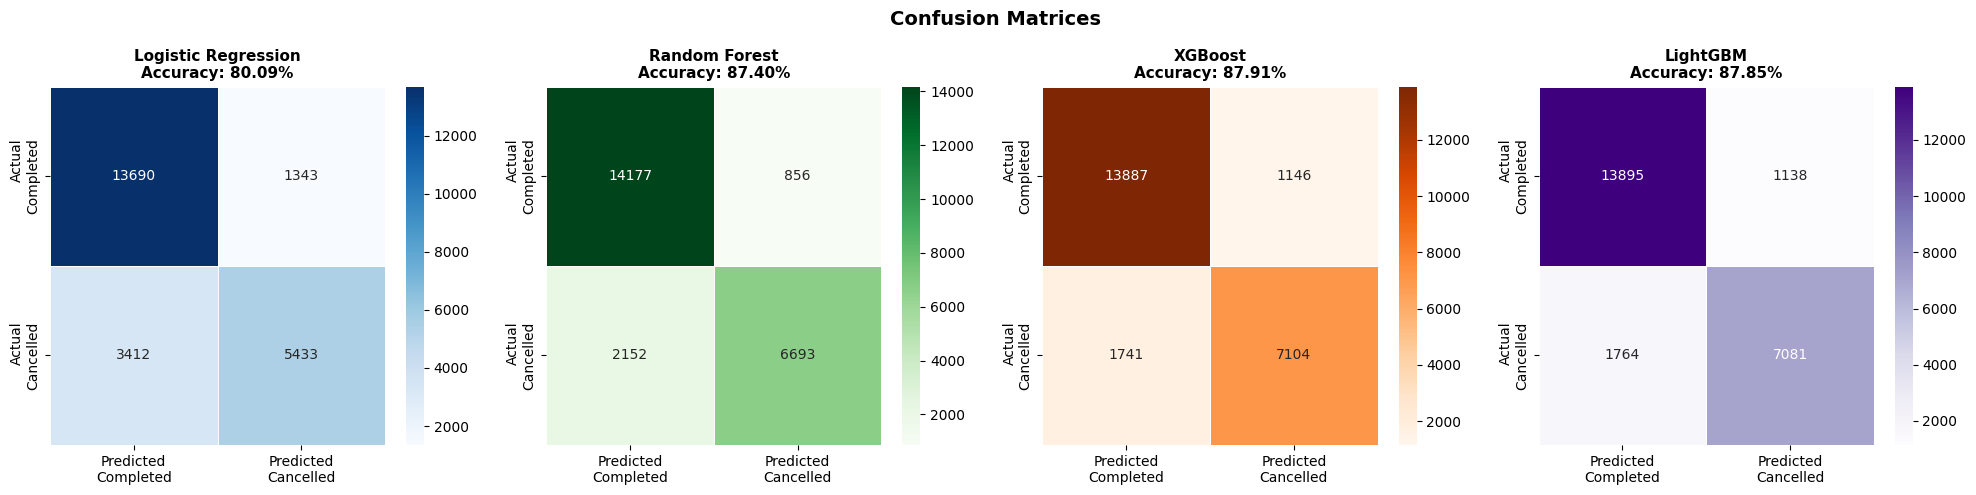

In [13]:
# Confusion Matrices 

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

models_cm = [
    ('Logistic Regression', lr_pred),
    ('Random Forest',       rf_pred),
    ('XGBoost',             xgb_pred),
    ('LightGBM',            lgb_pred)
]
colors_cm = ['Blues', 'Greens', 'Oranges', 'Purples']

for ax, (name, pred), cmap in zip(axes, models_cm, colors_cm):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                ax=ax, linewidths=0.5,
                xticklabels=['Predicted\nCompleted',
                             'Predicted\nCancelled'],
                yticklabels=['Actual\nCompleted',
                             'Actual\nCancelled'])
    acc = accuracy_score(y_test, pred) * 100
    ax.set_title(f'{name}\nAccuracy: {acc:.2f}%',
                 fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


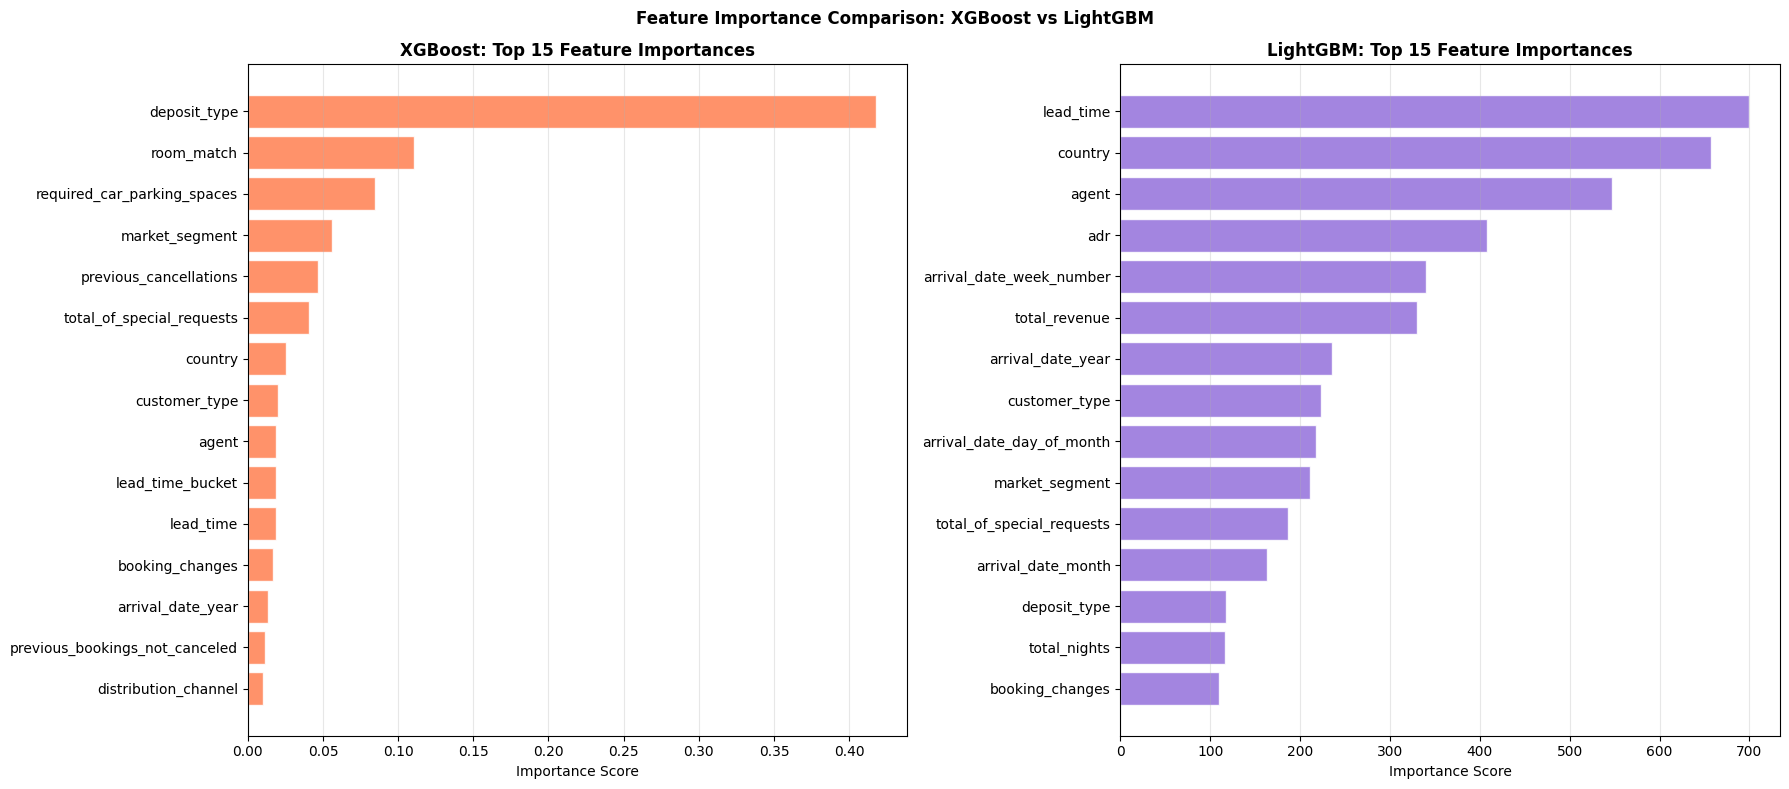

In [14]:
# Feature Importance: XGBoost and LightGBM

fig, axes = plt.subplots(1, 2, figsize=(18, 8))


xgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[0].barh(xgb_importance['feature'][::-1],
             xgb_importance['importance'][::-1],
             color='coral', edgecolor='white', alpha=0.85)
axes[0].set_title('XGBoost: Top 15 Feature Importances',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].grid(axis='x', alpha=0.3)


lgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[1].barh(lgb_importance['feature'][::-1],
             lgb_importance['importance'][::-1],
             color='mediumpurple', edgecolor='white', alpha=0.85)
axes[1].set_title('LightGBM: Top 15 Feature Importances',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance Comparison: XGBoost vs LightGBM',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [15]:
xgb_importance_gain = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

lgb_importance_gain = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

lgb_importance_gain2 = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model.booster_.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False).head(10)

print("XGBoost top 10 (gain):")
print(xgb_importance_gain.to_string(index=False))
print("\nLightGBM top 10 (gain):")
print(lgb_importance_gain2.to_string(index=False))

XGBoost top 10 (gain):
                    feature  importance
               deposit_type    0.417903
                 room_match    0.110438
required_car_parking_spaces    0.084336
             market_segment    0.056080
     previous_cancellations    0.046338
  total_of_special_requests    0.040972
                    country    0.025534
              customer_type    0.020026
                      agent    0.018833
           lead_time_bucket    0.018580

LightGBM top 10 (gain):
                    feature    importance
               deposit_type 104464.841961
                    country  55201.596359
                  lead_time  37753.265743
                      agent  35486.160045
  total_of_special_requests  25965.247426
             market_segment  23683.642079
                 room_match  20728.930483
required_car_parking_spaces  19676.123734
     previous_cancellations  14315.576315
              customer_type  12090.184329


====================================================================================================================================================================================================================================

# Section 5  Final Model Evaluation and Business Interpretation


In [16]:
# Section 5 Final Model Detailed Evaluation

print(f"\nTest set size: {len(y_test):,} bookings")
print(f"Actual cancellations: {y_test.sum():,} "
      f"({y_test.mean()*100:.1f}%)")

print(f"  Accuracy:  {accuracy_score(y_test, xgb_pred)*100:.2f}%")
print(f"  Precision: {precision_score(y_test, xgb_pred)*100:.2f}%")
print(f"  Recall:    {recall_score(y_test, xgb_pred)*100:.2f}%")
print(f"  F1 Score:  {f1_score(y_test, xgb_pred)*100:.2f}%")
print(f"  ROC-AUC:   {roc_auc_score(y_test, xgb_prob)*100:.2f}%")


cm = confusion_matrix(y_test, xgb_pred)
tn, fp, fn, tp = cm.ravel()
print(f"  True Negatives  (correctly predicted completed): {tn:,}")
print(f"  True Positives  (correctly predicted cancelled): {tp:,}")
print(f"  False Positives (completed predicted cancelled): {fp:,}")
print(f"  False Negatives (cancelled predicted completed): {fn:,}")
print(f"\n  Cancellations caught:  {tp:,} / {tp+fn:,} "
      f"({tp/(tp+fn)*100:.1f}%)")
print(f"  Cancellations missed:  {fn:,} / {tp+fn:,} "
      f"({fn/(tp+fn)*100:.1f}%)")
print(f"  False alarm rate:      {fp:,} / {tn+fp:,} "
      f"({fp/(tn+fp)*100:.1f}%)")

print(f"\nDetailed Classification Report:")
print(classification_report(y_test, xgb_pred,
      target_names=['Completed', 'Cancelled']))


Test set size: 23,878 bookings
Actual cancellations: 8,845 (37.0%)
  Accuracy:  87.91%
  Precision: 86.11%
  Recall:    80.32%
  F1 Score:  83.11%
  ROC-AUC:   95.29%
  True Negatives  (correctly predicted completed): 13,887
  True Positives  (correctly predicted cancelled): 7,104
  False Positives (completed predicted cancelled): 1,146
  False Negatives (cancelled predicted completed): 1,741

  Cancellations caught:  7,104 / 8,845 (80.3%)
  Cancellations missed:  1,741 / 8,845 (19.7%)
  False alarm rate:      1,146 / 15,033 (7.6%)

Detailed Classification Report:
              precision    recall  f1-score   support

   Completed       0.89      0.92      0.91     15033
   Cancelled       0.86      0.80      0.83      8845

    accuracy                           0.88     23878
   macro avg       0.87      0.86      0.87     23878
weighted avg       0.88      0.88      0.88     23878



In [17]:
# Business Impact Analysis

avg_adr = df[df['is_canceled']==0]['adr'].mean()
avg_nights = df[df['is_canceled']==0]['total_nights'].mean()
avg_booking_value = avg_adr * avg_nights

cm = confusion_matrix(y_test, xgb_pred)
tn, fp, fn, tp = cm.ravel()

scale = len(df) / len(y_test)

tp_full = int(tp * scale)
fn_full = int(fn * scale)
fp_full = int(fp * scale)

print(f"\nAssumptions:")
print(f"  Average ADR:           ${avg_adr:.2f}")
print(f"  Average stay length:   {avg_nights:.1f} nights")
print(f"  Average booking value: ${avg_booking_value:.2f}")

print(f"\nOn full dataset ({len(df):,} bookings):")
print(f"  Cancellations correctly flagged: {tp_full:,}")
print(f"  Cancellations missed:            {fn_full:,}")
print(f"  False alarms:                    {fp_full:,}")

print(f"\nRevenue Protection Potential:")
revenue_protected = tp_full * avg_booking_value * 0.3
print(f"  If hotel recovers 30% of flagged cancellations")
print(f"  through retention actions (deposits, upgrades,")
print(f"  reminder emails):")
print(f"  Estimated revenue protected: "
      f"${revenue_protected:,.0f}")

print(f"\nFalse Alarm Cost:")
false_alarm_cost = fp_full * 5
print(f"  Cost per false alarm (retention email): ~$5")
print(f"  Total false alarm cost: ${false_alarm_cost:,.0f}")

print(f"\nNet Business Value:")
net_value = revenue_protected - false_alarm_cost
print(f"  Revenue protected - False alarm cost")
print(f"  = ${revenue_protected:,.0f} - ${false_alarm_cost:,.0f}")
print(f"  = ${net_value:,.0f}")


Assumptions:
  Average ADR:           $99.99
  Average stay length:   3.4 nights
  Average booking value: $339.26

On full dataset (119,390 bookings):
  Cancellations correctly flagged: 35,520
  Cancellations missed:            8,705
  False alarms:                    5,730

Revenue Protection Potential:
  If hotel recovers 30% of flagged cancellations
  through retention actions (deposits, upgrades,
  reminder emails):
  Estimated revenue protected: $3,615,155

False Alarm Cost:
  Cost per false alarm (retention email): ~$5
  Total false alarm cost: $28,650

Net Business Value:
  Revenue protected - False alarm cost
  = $3,615,155 - $28,650
  = $3,586,505


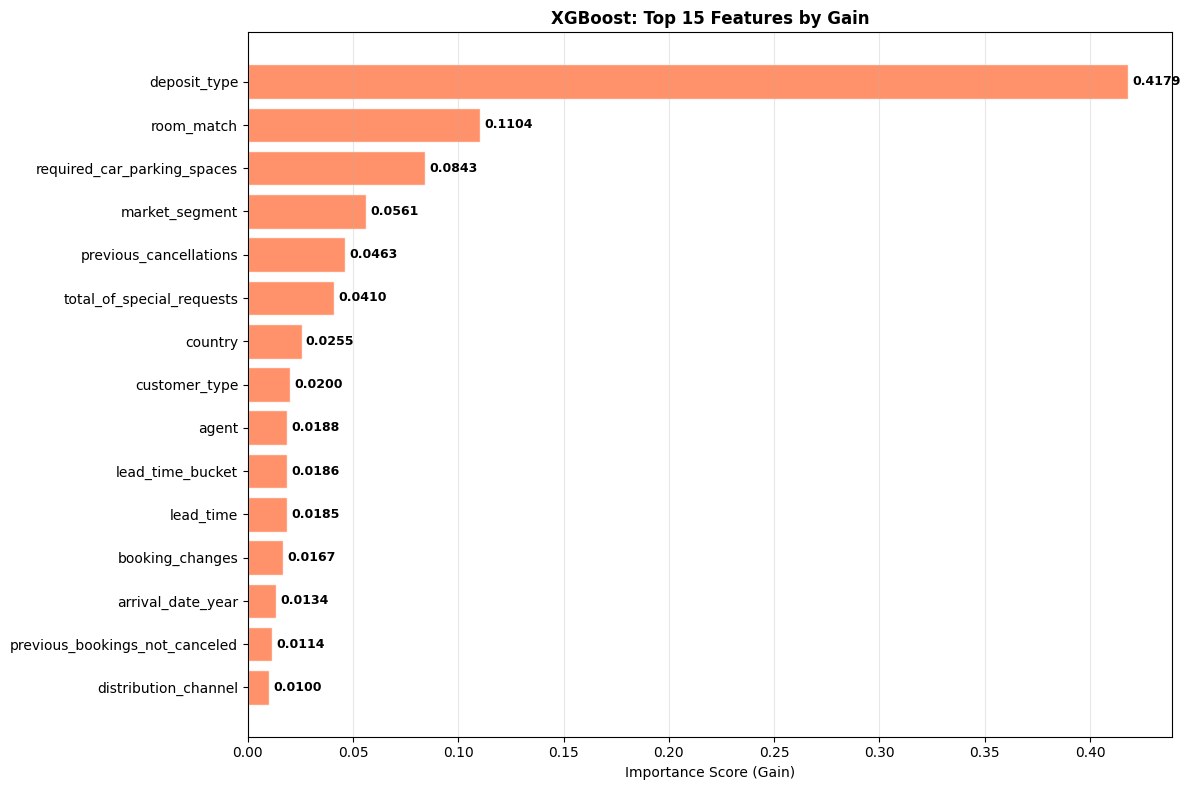

In [18]:
# Final Feature Importance , XGBoost gain-based

xgb_importance_final = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(xgb_importance_final['feature'][::-1],
               xgb_importance_final['importance'][::-1],
               color='coral', edgecolor='white', alpha=0.85)

for bar, val in zip(bars,
                    xgb_importance_final['importance'][::-1]):
    ax.text(bar.get_width() + 0.002,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center',
            fontsize=9, fontweight='bold')

ax.set_title('XGBoost: Top 15 Features by Gain',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score (Gain)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


====================================================================================================================================================================================================================================

# Section 6 Key Findings Summary

**Model Performance Summary:**

- Recall is the most important metric for hotel cancellation prediction. A missed cancellation costs the hotel a full booking value ($339 average). A false alarm 
costs only a retention email (~$5). XGBoost achieves the best recall (80.32%) among all models.

- The top 3 features alone (deposit_type, room_match, parking) account for over 60% of the model's predictive power. All three are behavioural commitment signals identified independently in the SQL analysis (Week 1) and statistical tests (Week 3).

**Operational Recommendations from ML Model:**

**Recommendation 1 Real-Time Risk Scoring**
Deploy XGBoost as a real-time API. Every new booking receives a cancellation probability score (0 to 1) at the moment of reservation. Bookings above 0.5 probability trigger automated retention workflows.

**Recommendation 2 Tiered Intervention Strategy**
Use predicted probability to tier the response:
- 0.5 to 0.65: send booking confirmation reminder at 30 days
- 0.65 to 0.80: offer room upgrade or flexible date change
- 0.80 or above: require deposit or non-refundable rate

**Recommendation 3 Threshold Adjustment**
Default threshold is 0.5. For hotel use, lowering to 0.35 increases recall (catches more cancellations) at the cost of more false alarms. Given the asymmetric costs ($339 missed vs $5 false alarm), a lower threshold is financially justified.

**Recommendation 4  Overbooking Optimisation**
Use predicted cancellation probability to calculate expected occupancy more accurately. Instead of flat overbooking rates, apply booking-level probabilities to forecast actual arrivals and optimise room inventory dynamically.

====================================================================================================================================================================================================================================

# Save the XGBoost Model for deployment

In [20]:
import joblib
import os

models_path = r'C:\Users\sadeq\Desktop\Python\Hotel_Booking\models'
os.makedirs(models_path, exist_ok=True)

joblib.dump(xgb_model, f'{models_path}\\xgb_model.pkl')

joblib.dump(list(X_encoded.columns), f'{models_path}\\feature_columns.pkl')


cat_mappings = {}
for col in cat_cols:
    cat_mappings[col] = sorted(df[col].astype(str).unique().tolist())
joblib.dump(cat_mappings, f'{models_path}\\cat_mappings.pkl')

['C:\\Users\\sadeq\\Desktop\\Python\\Hotel_Booking\\models\\cat_mappings.pkl']